
# 3. Resampling & Dataset

Convert variable-length rep segments into a fixed-shape tensor ready for LSTM training.

```
Rep segments  (T_i frames, F features each)   — variable T_i  (~5–20 frames)
   ↓
scipy.interpolate  →  T_fixed frames (data-driven, typically 16–20)
   ↓
Z-score normalisation  (using feature_stats.json)
   ↓
X  shape (N_reps, T_fixed, F)    dtype float32
y  shape (N_reps,)                dtype int8   (0=wrong, 1=correct)
   ↓
Saved as feature_engineering/data/dataset/X.npy + y.npy
```

**Why upsample short clips?**  
Most reps in this dataset are 8–16 frames. Resampling to T_fixed=20 doubles the temporal resolution
via linear interpolation — the shape of the curve is preserved but the LSTM gets more timesteps
to detect subtle joint-angle dynamics.

**Depends on:** `2.rep_segmentation.ipynb` — segment JSONs in `feature_engineering/data/segments/`


In [4]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT       = Path('..').resolve()
FE_DIR     = ROOT / 'feature_engineering'
SEG_DIR    = FE_DIR / 'data' / 'segments'
STATS_PATH = FE_DIR / 'data' / 'feature_stats.json'
DS_DIR     = FE_DIR / 'data' / 'dataset'
DS_DIR.mkdir(parents=True, exist_ok=True)

# Load segmentation config (for suggested T_fixed)
seg_cfg_path = FE_DIR / 'data' / 'seg_config.json'
if not seg_cfg_path.exists():
    raise FileNotFoundError('Run 2.rep_segmentation.ipynb first.')

seg_cfg = json.loads(seg_cfg_path.read_text())
print('Segmentation config:', json.dumps(seg_cfg, indent=2))

Segmentation config: {
  "smooth_k": 5,
  "distance": 8,
  "prominence": 5,
  "padding": 3,
  "n_videos": 152,
  "n_reps": 157,
  "label_counts": {
    "correct": 76,
    "wrong": 81
  },
  "rep_length_p10": 7,
  "rep_length_p50": 11,
  "rep_length_p75": 14,
  "rep_length_p90": 15,
  "suggested_T_fixed": 14
}


In [5]:
# ── Load feature stats for normalisation ─────────────────────────────────────
if not STATS_PATH.exists():
    raise FileNotFoundError('Run 1.feature_engineering.ipynb first.')

stats_data   = json.loads(STATS_PATH.read_text())
FEATURE_COLS = stats_data['feature_cols']
feat_stats   = stats_data['stats']

F = len(FEATURE_COLS)
print(f'Feature cols F = {F}:')
for i, c in enumerate(FEATURE_COLS):
    print(f'  {i:2d}  {c}')

Feature cols F = 15:
   0  left_elbow_angle
   1  right_elbow_angle
   2  mean_elbow_angle
   3  elbow_symmetry
   4  left_hip_angle
   5  right_hip_angle
   6  body_straightness
   7  shoulder_height_norm
   8  hip_height_norm
   9  shoulder_velocity
  10  hip_velocity
  11  elbow_angle_velocity
  12  wrist_width_norm
  13  shoulder_width_norm
  14  nose_height_norm


## 3.1 Choose T_fixed

In [6]:

# T_fixed strategy:
#   - Start from p90 rep length (so ~90% of reps are upsampled, not truncated)
#   - Upsample to at least 20 frames so the LSTM has enough timesteps
#   - Cap at 80 to avoid memory waste on outlier long clips
p90_len = seg_cfg.get('rep_length_p90', 20)
T_FIXED = max(20, min(p90_len, 80))

# ── Manual override (uncomment to set explicitly) ─────────────────────────────
# T_FIXED = 20

print(f'Rep length percentiles:')
print(f'  p10={seg_cfg["rep_length_p10"]}  '
      f'p50={seg_cfg["rep_length_p50"]}  '
      f'p75={seg_cfg["rep_length_p75"]}  '
      f'p90={seg_cfg["rep_length_p90"]}')
print()
print(f'T_fixed = {T_FIXED} frames per rep')
n_upsample  = seg_cfg['n_reps'] - 0   # placeholder, shown below
print(f'  → reps shorter than {T_FIXED} frames will be UPSAMPLED (linear interp)')
print(f'  → reps longer  than {T_FIXED} frames will be DOWNSAMPLED (linear interp)')


Rep length percentiles:
  p10=7  p50=11  p75=14  p90=15

T_fixed = 20 frames per rep
  → reps shorter than 20 frames will be UPSAMPLED (linear interp)
  → reps longer  than 20 frames will be DOWNSAMPLED (linear interp)


## 3.2 Resampling

In [7]:

def resample_rep(feat_list: list[dict], t_fixed: int = T_FIXED) -> np.ndarray:
    """
    Resample a variable-length rep to t_fixed frames using linear interpolation.
    Works for both upsampling (short clips) and downsampling (long clips).

    Edge cases handled:
      T_orig == 1  → repeat the single frame t_fixed times
      T_orig == 2  → linear interp still works fine
      T_orig == t_fixed → return as-is (no interp needed)

    Input : list of T_i feature-dicts
    Output: (t_fixed, F) float32 array
    """
    T_orig = len(feat_list)
    F_local = len(FEATURE_COLS)

    # Build (T_orig, F) matrix
    mat = np.array([[f.get(col, 0.0) for col in FEATURE_COLS]
                    for f in feat_list], dtype=np.float32)

    # Edge case: single frame — tile it
    if T_orig == 1:
        return np.tile(mat, (t_fixed, 1))

    # Already the right length
    if T_orig == t_fixed:
        return mat

    t_old = np.linspace(0, 1, T_orig)
    t_new = np.linspace(0, 1, t_fixed)

    out = np.zeros((t_fixed, F_local), dtype=np.float32)
    for j in range(F_local):
        interp_fn = interp1d(t_old, mat[:, j], kind='linear',
                             fill_value='extrapolate')
        out[:, j] = interp_fn(t_new)

    return out


# Quick sanity check on a dummy rep
_dummy = [{'mean_elbow_angle': float(v), **{c: 0.0 for c in FEATURE_COLS}} for v in range(8)]
_out   = resample_rep(_dummy, t_fixed=T_FIXED)
assert _out.shape == (T_FIXED, len(FEATURE_COLS)), 'resample_rep shape mismatch!'
print(f'resample_rep() ready.  8→{T_FIXED} frames: output shape {_out.shape}')
del _dummy, _out


resample_rep() ready.  8→20 frames: output shape (20, 15)


## 3.3 Z-score Normalisation

In [8]:
# Build mean and std vectors from global feature stats
FEAT_MEAN = np.array([feat_stats[c]['mean'] for c in FEATURE_COLS], dtype=np.float32)
FEAT_STD  = np.array([feat_stats[c]['std']  for c in FEATURE_COLS], dtype=np.float32)
FEAT_STD  = np.where(FEAT_STD < 1e-6, 1.0, FEAT_STD)   # avoid div-by-zero


def normalise(x: np.ndarray) -> np.ndarray:
    """x: (T, F) → z-score normalised (T, F)."""
    return (x - FEAT_MEAN) / FEAT_STD


print('Normalisation ready.')
print(f'FEAT_MEAN: {FEAT_MEAN.round(3)}')
print(f'FEAT_STD : {FEAT_STD.round(3)}')

Normalisation ready.
FEAT_MEAN: [1.47252e+02 1.47885e+02 1.47477e+02 1.20020e+01 1.49413e+02 1.49293e+02
 4.30000e-02 4.74000e-01 5.25000e-01 2.00000e-03 2.00000e-03 7.70000e-02
 5.80000e-02 5.50000e-02 5.19000e-01]
FEAT_STD : [29.953 28.158 27.566 14.755 25.117 22.064  0.039  0.145  0.121  0.077
  0.057 22.311  0.047  0.035  0.15 ]


## 3.4 Build the Full Dataset

In [9]:

LABEL_MAP = {'correct': 1, 'wrong': 0}
AUGMENT   = False   # default; may be set True in section 3.7

X_list, y_list, meta = [], [], []
n_upsampled = n_downsampled = n_exact = 0

for seg_file in tqdm(sorted(SEG_DIR.glob('*.json')), desc='Resampling'):
    segments = json.loads(seg_file.read_text())
    for seg in segments:
        feats = seg['features']
        if len(feats) < 2:
            continue   # skip degenerate single-frame segments (< 2 frames)

        orig_len = len(feats)
        if   orig_len < T_FIXED: n_upsampled   += 1
        elif orig_len > T_FIXED: n_downsampled += 1
        else:                    n_exact       += 1

        x = resample_rep(feats, t_fixed=T_FIXED)   # (T_FIXED, F)
        x = normalise(x)                             # (T_FIXED, F)

        label_str = seg['label']
        y_val     = LABEL_MAP.get(label_str, -1)
        if y_val < 0:
            continue

        X_list.append(x)
        y_list.append(y_val)
        meta.append({
            'video'       : seg['video'],
            'rep_idx'     : seg['rep_idx'],
            'label'       : label_str,
            'orig_length' : orig_len,
            'augmented'   : False,
        })

X = np.stack(X_list, axis=0).astype(np.float32)
y = np.array(y_list, dtype=np.int8)

print(f'X shape : {X.shape}   (N_reps, T_fixed={T_FIXED}, F={len(FEATURE_COLS)})')
print(f'y shape : {y.shape}')
print(f'Class balance:  correct={int(y.sum())}/{len(y)} '
      f'({100*y.mean():.1f}%)  |  wrong={int((y==0).sum())}/{len(y)}')
print()
print(f'Resampling breakdown (target T={T_FIXED}):')
print(f'  Upsampled   (orig < {T_FIXED}) : {n_upsampled}')
print(f'  Downsampled (orig > {T_FIXED}) : {n_downsampled}')
print(f'  Exact       (orig = {T_FIXED}) : {n_exact}')


Resampling: 100%|██████████| 152/152 [00:00<00:00, 1793.11it/s]

X shape : (157, 20, 15)   (N_reps, T_fixed=20, F=15)
y shape : (157,)
Class balance:  correct=76/157 (48.4%)  |  wrong=81/157

Resampling breakdown (target T=20):
  Upsampled   (orig < 20) : 153
  Downsampled (orig > 20) : 0
  Exact       (orig = 20) : 4


## 3.5 Verify Resampled Samples

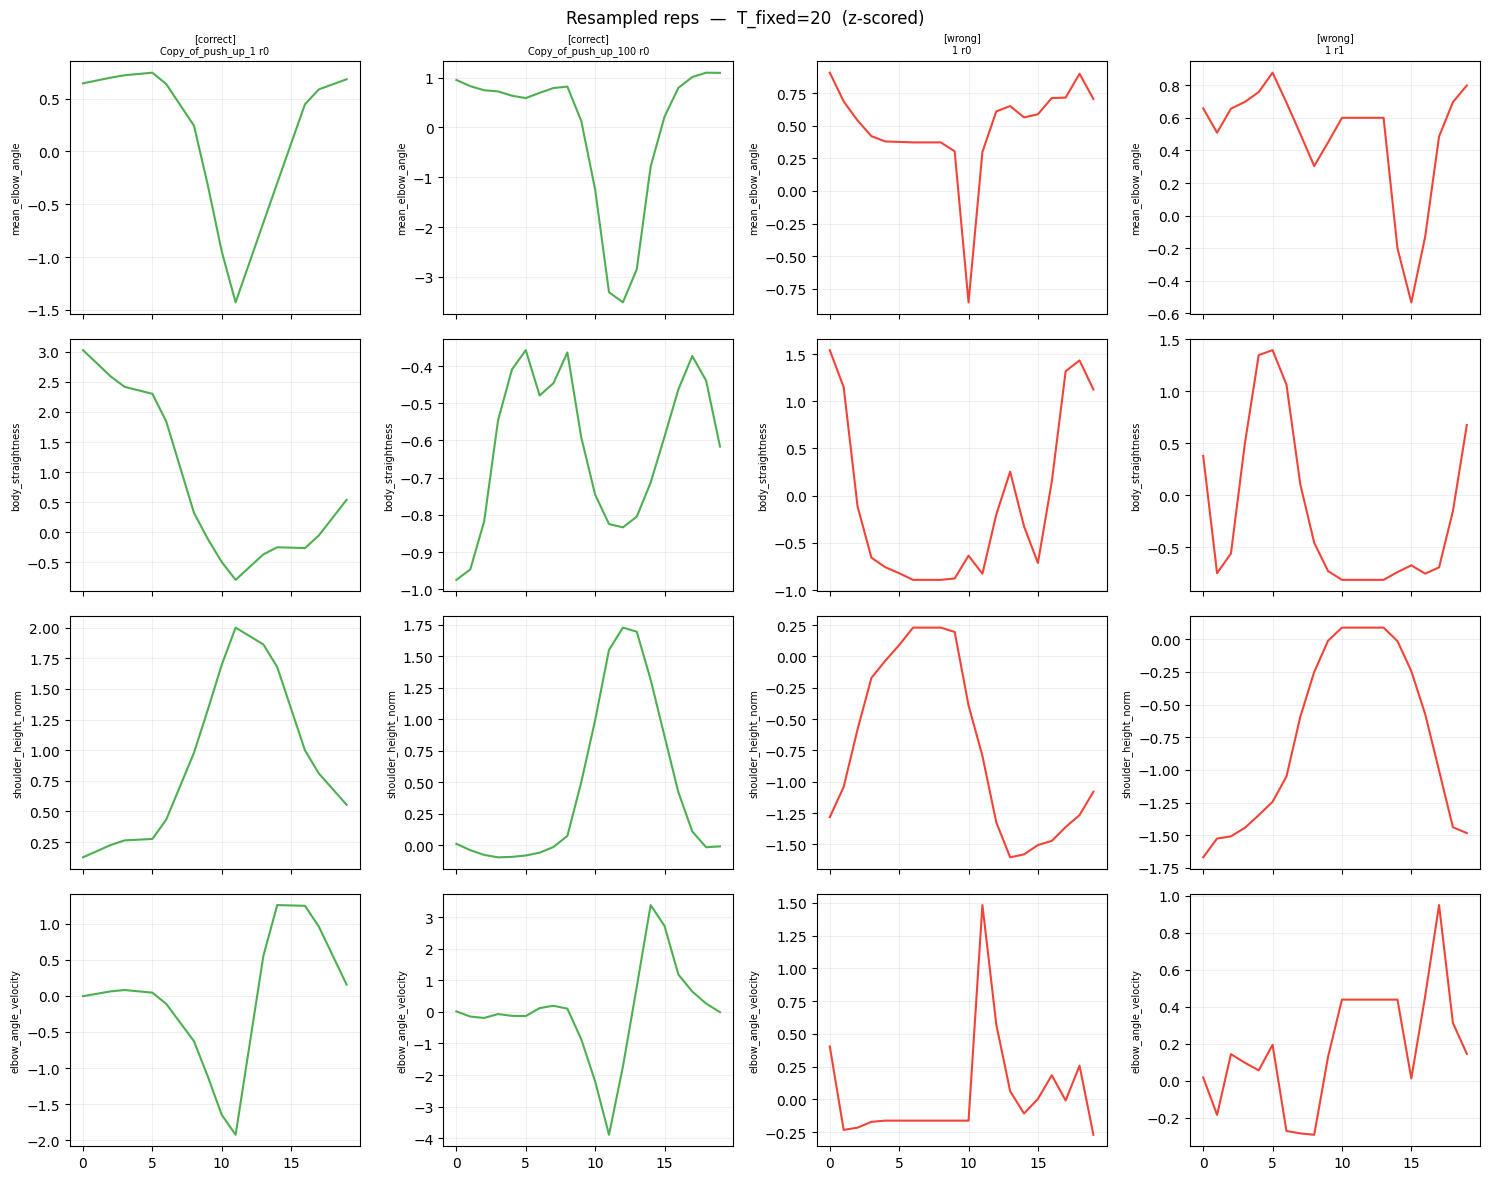

In [10]:
# Pick 4 reps (2 correct, 2 wrong) and visualise all features
correct_idx = np.where(y == 1)[0][:2]
wrong_idx   = np.where(y == 0)[0][:2]
sample_idx  = list(correct_idx) + list(wrong_idx)

SHOW_COLS = ['mean_elbow_angle', 'body_straightness',
             'shoulder_height_norm', 'elbow_angle_velocity']
show_ci = [FEATURE_COLS.index(c) for c in SHOW_COLS if c in FEATURE_COLS]

fig, axes = plt.subplots(len(show_ci), len(sample_idx),
                         figsize=(15, 3 * len(show_ci)), sharex=True)

for j, idx in enumerate(sample_idx):
    lbl   = 'correct' if y[idx]==1 else 'wrong'
    color = '#4CAF50' if y[idx]==1 else '#F44336'
    m     = meta[idx]
    for row, ci in enumerate(show_ci):
        ax = axes[row][j] if len(show_ci) > 1 else axes[j]
        ax.plot(X[idx, :, ci], color=color, lw=1.5)
        if row == 0:
            ax.set_title(f'[{lbl}]\n{m["video"]} r{m["rep_idx"]}', fontsize=7)
        ax.set_ylabel(SHOW_COLS[row], fontsize=7)
        ax.grid(alpha=0.2)

fig.suptitle(f'Resampled reps  —  T_fixed={T_FIXED}  (z-scored)', fontsize=12)
plt.tight_layout()
plt.show()

## 3.6 Class Balance & Augmentation Guidance

Correct reps : 76
Wrong reps   : 81
Imbalance ratio: 1.07x

✓ Class balance is acceptable.


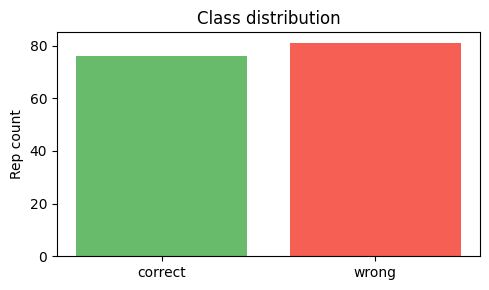

In [11]:
n_correct = int(y.sum())
n_wrong   = int((y==0).sum())
ratio     = max(n_correct, n_wrong) / (min(n_correct, n_wrong) + 1e-9)

print(f'Correct reps : {n_correct}')
print(f'Wrong reps   : {n_wrong}')
print(f'Imbalance ratio: {ratio:.2f}x')

if ratio > 2:
    minority  = 'wrong' if n_wrong < n_correct else 'correct'
    minority_y = 0 if minority == 'wrong' else 1
    print(f'\n⚠  Imbalance > 2x. Consider:')
    print(f'   1. class_weight in loss function')
    print(f'   2. Time-reversal augmentation on minority class ({minority})')
    print(f'   3. Add jitter noise augmentation')
else:
    print('\n✓ Class balance is acceptable.')

# Histogram
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['correct', 'wrong'], [n_correct, n_wrong],
       color=['#4CAF50', '#F44336'], alpha=0.85)
ax.set_ylabel('Rep count')
ax.set_title('Class distribution')
plt.tight_layout()
plt.show()

## 3.7 (Optional) Time-Reversal Augmentation

Flip minority reps in time.  A push-up played backwards is biomechanically similar — the arm goes from extended → bent → extended, which is physiologically plausible and preserves class-relevant features.

In [12]:

AUGMENT = ratio > 2.0   # True if class imbalance is meaningful

if AUGMENT:
    minority_y     = 0 if n_wrong < n_correct else 1
    minority_label = 'wrong' if minority_y == 0 else 'correct'
    minority_X     = X[y == minority_y]

    # Time-reverse along the time axis — preserves the V-shaped elbow curve
    aug_X = minority_X[:, ::-1, :].copy()

    # Small Gaussian jitter for added diversity (σ = 0.02 normalised units)
    rng_gen = np.random.default_rng(42)
    aug_X  += rng_gen.normal(0, 0.02, aug_X.shape).astype(np.float32)

    aug_y    = np.full(len(aug_X), minority_y, dtype=np.int8)
    aug_meta = [
        {**m, 'video': m['video'] + '_aug', 'augmented': True}
        for m in meta if m['label'] == minority_label
    ]

    X    = np.concatenate([X, aug_X], axis=0)
    y    = np.concatenate([y, aug_y], axis=0)
    meta = meta + aug_meta

    print(f'After augmentation: {len(X)} reps  '
          f'({int(y.sum())} correct / {int((y==0).sum())} wrong)')
else:
    print('Augmentation skipped (class balance OK).')

print(f'Final X shape: {X.shape}')


Augmentation skipped (class balance OK).
Final X shape: (157, 20, 15)


## 3.8 Save Dataset

In [13]:

np.save(DS_DIR / 'X.npy', X)
np.save(DS_DIR / 'y.npy', y)

# Save meta as CSV for inspection
df_meta = pd.DataFrame(meta)
df_meta.to_csv(DS_DIR / 'meta.csv', index=False)

# Save dataset config (all info needed to reproduce inference-time normalisation)
ds_cfg = {
    'T_fixed'         : T_FIXED,
    'F'               : F,
    'feature_cols'    : FEATURE_COLS,
    'n_reps'          : len(X),
    'n_correct'       : int(y.sum()),
    'n_wrong'         : int((y==0).sum()),
    'label_map'       : LABEL_MAP,
    'feat_mean'       : FEAT_MEAN.tolist(),
    'feat_std'        : FEAT_STD.tolist(),
    'augmented'       : bool(AUGMENT),
    'n_augmented'     : int(sum(1 for m in meta if m.get('augmented'))),
    'resampling'      : {
        'n_upsampled'  : n_upsampled,
        'n_downsampled': n_downsampled,
        'n_exact'      : n_exact,
    },
}
(DS_DIR / 'dataset_config.json').write_text(json.dumps(ds_cfg, indent=2))

print('Saved:')
print(f'  X.npy              {X.nbytes/1024:.1f} KB  {X.shape}')
print(f'  y.npy              {y.nbytes} B    {y.shape}')
print(f'  meta.csv           {len(df_meta)} rows')
print(f'  dataset_config.json')
print()
print(json.dumps(ds_cfg, indent=2))


Saved:
  X.npy              184.0 KB  (157, 20, 15)
  y.npy              157 B    (157,)
  meta.csv           157 rows
  dataset_config.json

{
  "T_fixed": 20,
  "F": 15,
  "feature_cols": [
    "left_elbow_angle",
    "right_elbow_angle",
    "mean_elbow_angle",
    "elbow_symmetry",
    "left_hip_angle",
    "right_hip_angle",
    "body_straightness",
    "shoulder_height_norm",
    "hip_height_norm",
    "shoulder_velocity",
    "hip_velocity",
    "elbow_angle_velocity",
    "wrist_width_norm",
    "shoulder_width_norm",
    "nose_height_norm"
  ],
  "n_reps": 157,
  "n_correct": 76,
  "n_wrong": 81,
  "label_map": {
    "correct": 1,
    "wrong": 0
  },
  "feat_mean": [
    147.2523193359375,
    147.884765625,
    147.47669982910156,
    12.001997947692871,
    149.4132080078125,
    149.29331970214844,
    0.043202001601457596,
    0.4738849997520447,
    0.5246520042419434,
    0.001547000021673739,
    0.0016410000389441848,
    0.0767500028014183,
    0.05814899876713753,
  

## 3.9 Verify Dataset Files

In [14]:

X_check = np.load(DS_DIR / 'X.npy')
y_check = np.load(DS_DIR / 'y.npy')

N_expected = len(X)   # final count after optional augmentation

assert X_check.shape == (N_expected, T_FIXED, F), \
    f'Shape mismatch! Got {X_check.shape}, expected ({N_expected}, {T_FIXED}, {F})'
assert y_check.shape == (N_expected,), \
    f'Label count mismatch! Got {y_check.shape}, expected ({N_expected},)'
assert not np.any(np.isnan(X_check)), 'NaN values detected in X!'
assert not np.any(np.isinf(X_check)), 'Inf values detected in X!'

print('✓ All checks passed.')
print(f'  X : {X_check.shape}  dtype={X_check.dtype}  '
      f'range=[{X_check.min():.2f}, {X_check.max():.2f}]')
print(f'  y : {y_check.shape}  dtype={y_check.dtype}  '
      f'unique values={np.unique(y_check)}')
print(f'  augmented reps: {sum(1 for m in meta if m.get("augmented"))}')


✓ All checks passed.
  X : (157, 20, 15)  dtype=float32  range=[-5.65, 6.56]
  y : (157,)  dtype=int8  unique values=[0 1]
  augmented reps: 0


## 3.10 Final PCA Sanity Check

Project each rep's `(T_fixed × F)` feature tensor into 2D via PCA to confirm correct and wrong form are separable.

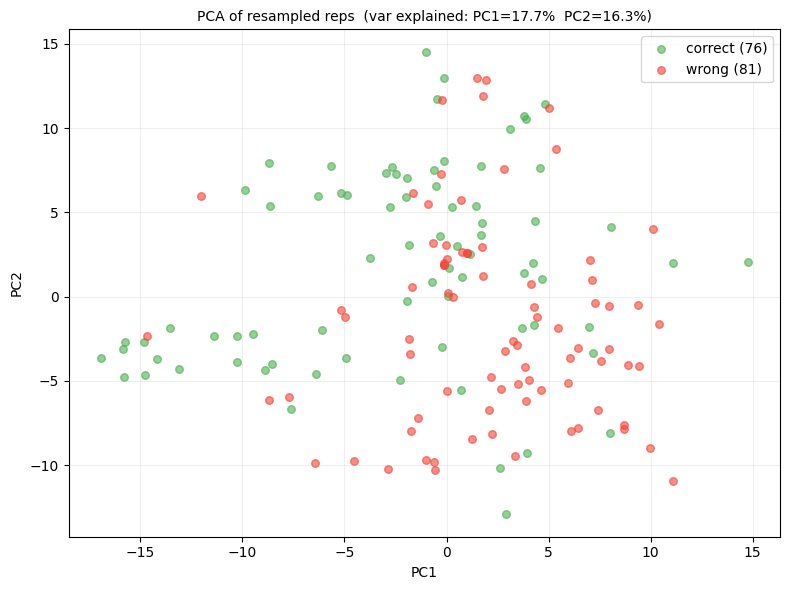

If the two clouds are separated, feature engineering is working well.


In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Flatten each rep into a 1-D vector: (N, T*F)
X_flat = X_check.reshape(len(X_check), -1)

# PCA → 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_flat)

fig, ax = plt.subplots(figsize=(8, 6))
for lbl, label_str, c in [(1,'correct','#4CAF50'), (0,'wrong','#F44336')]:
    mask = y_check == lbl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=c, alpha=0.6, s=30, label=f'{label_str} ({mask.sum()})')

ax.set_title(
    f'PCA of resampled reps  '
    f'(var explained: PC1={pca.explained_variance_ratio_[0]:.1%}  '
    f'PC2={pca.explained_variance_ratio_[1]:.1%})',
    fontsize=10)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print('If the two clouds are separated, feature engineering is working well.')

## 3.11 Summary

| Artifact | Shape | Description |
|---|---|---|
| `dataset/X.npy` | `(N, T_fixed, F)` | Normalised feature tensor |
| `dataset/y.npy` | `(N,)` | Labels  0=wrong, 1=correct |
| `dataset/meta.csv` | N rows | Video, rep index, label, length |
| `dataset/dataset_config.json` | — | T, F, mean/std, label map |

**Next stage: Stage 6 — LSTM Form Classifier**

Load with:
```python
import numpy as np, json
from pathlib import Path

DS_DIR = Path('feature_engineering/data/dataset')
X = np.load(DS_DIR / 'X.npy')   # (N, T_fixed, F)
y = np.load(DS_DIR / 'y.npy')   # (N,)
cfg = json.loads((DS_DIR / 'dataset_config.json').read_text())
T, F = cfg['T_fixed'], cfg['F']
```